In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2
from matplotlib import font_manager

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体 (SimHei) 字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取CSV文件
data = pd.read_csv('D1-TaLEs-Second-locally/Data1.csv')

# 将 X 和 Y 转换为数值类型，忽略非数值内容并用 NaN 替代
X = pd.to_numeric(data.iloc[1:, 0], errors='coerce')
Y = pd.to_numeric(data.iloc[1:, 1], errors='coerce')

# 删除包含 NaN 的行
X = X.dropna().reset_index(drop=True)
Y = Y.dropna().reset_index(drop=True)

# 确保 X 和 Y 的长度一致
min_length = min(len(X), len(Y))
X = X[:min_length]
Y = Y[:min_length]

X-Y 相关性: 0.011880723882479752
X 数据自相关性: 0.018798390984191494
Y 数据自相关性: -0.001794624607396517
简化卡方值: 432.4748276188458, p 值: 1.595701958997669e-87


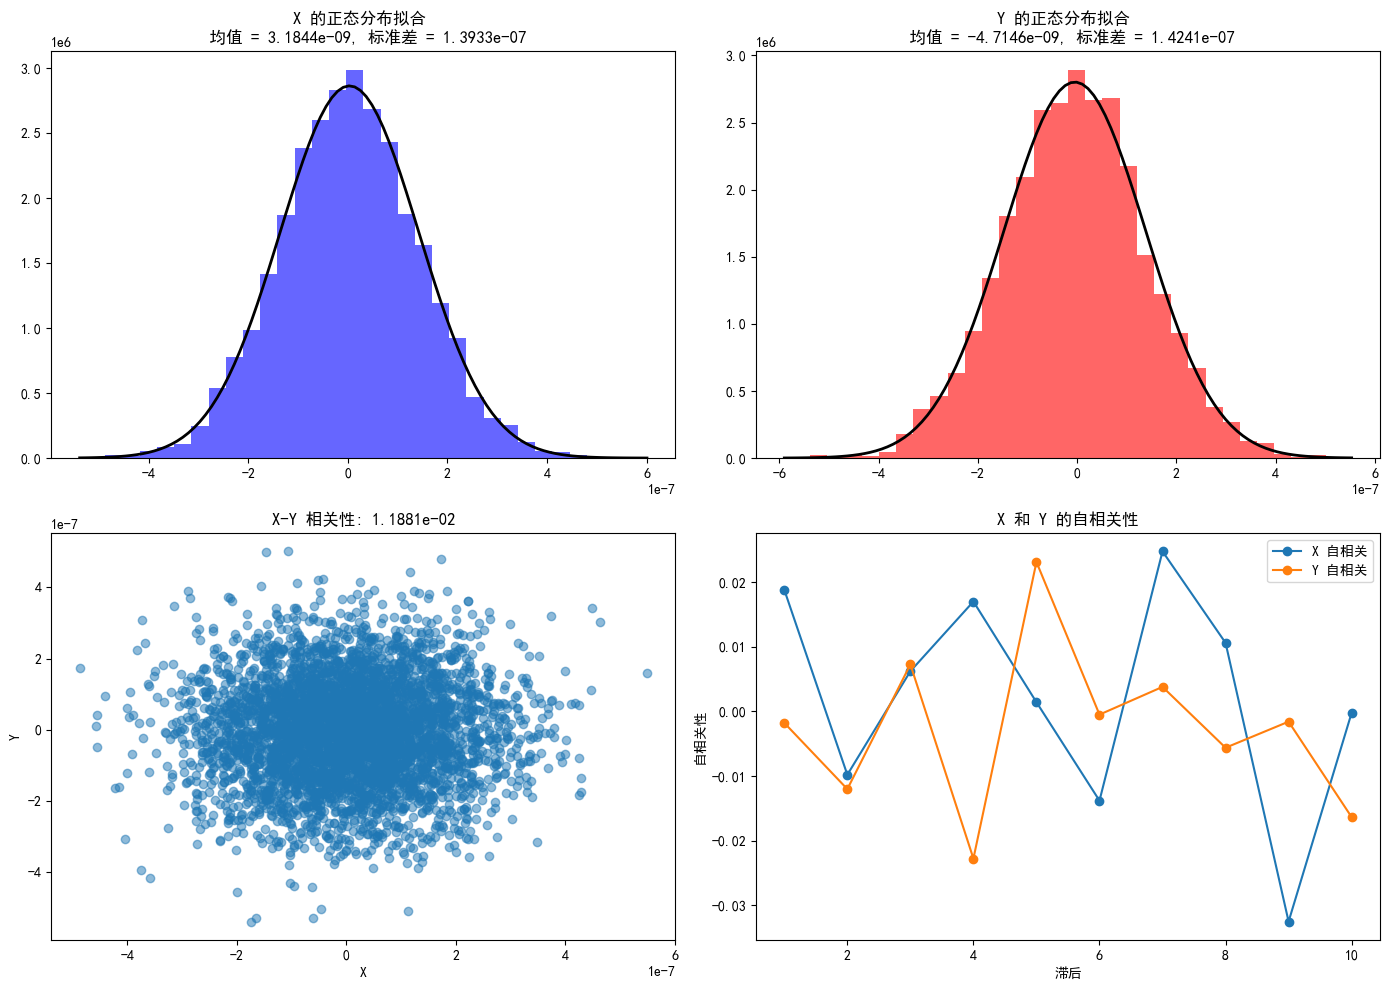

In [2]:
# 计算相关性
correlation = np.corrcoef(X, Y)[0, 1]
print(f"X-Y 相关性: {correlation}")

# 自相关性函数
def autocorrelation(data, lag=1):
    return np.corrcoef(data[:-lag], data[lag:])[0, 1]

# 计算 X 和 Y 的自相关性
autocorr_X = autocorrelation(X)
autocorr_Y = autocorrelation(Y)
print(f"X 数据自相关性: {autocorr_X}")
print(f"Y 数据自相关性: {autocorr_Y}")

# 正态分布拟合
mu_X, std_X = stats.norm.fit(X)
mu_Y, std_Y = stats.norm.fit(Y)

# 绘制正态分布拟合图
plt.figure(figsize=(14, 10))

# X 的正态分布拟合
plt.subplot(2, 2, 1)
plt.hist(X, bins=30, density=True, alpha=0.6, color='blue')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_X, std_X)
plt.plot(x, p, 'k', linewidth=2)
# plt.title(f'X 的正态分布拟合\n均值 = {mu_X:.10f}, 标准差 = {std_X:.10f}')
plt.title(f'X 的正态分布拟合 \n 均值 = {mu_X:.4e}, 标准差 = {std_X:.4e}')


# Y 的正态分布拟合
plt.subplot(2, 2, 2)
plt.hist(Y, bins=30, density=True, alpha=0.6, color='red')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_Y, std_Y)
plt.plot(x, p, 'k', linewidth=2)
plt.title(f'Y 的正态分布拟合 \n 均值 = {mu_Y:.4e}, 标准差 = {std_Y:.4e}')

# 简化卡方检验：先对 X 和 Y 进行分箱处理，确保数据符合卡方检验的离散性要求
bins = 10
X_binned, _ = np.histogram(X, bins=bins)
Y_binned, _ = np.histogram(Y, bins=bins)

# 卡方检验
chi2_val, p_val = stats.chisquare(Y_binned, f_exp=X_binned)
print(f"简化卡方值: {chi2_val}, p 值: {p_val}")

# 绘制散点图来展示 X 和 Y 的关系
plt.subplot(2, 2, 3)
plt.scatter(X, Y, alpha=0.5)
plt.title(f"X-Y 相关性: {correlation:.4e}")
plt.xlabel("X")
plt.ylabel("Y")

# 绘制自相关性图（简单的滞后自相关）
lags = range(1, 11)
autocorr_X_vals = [autocorrelation(X, lag) for lag in lags]
autocorr_Y_vals = [autocorrelation(Y, lag) for lag in lags]

plt.subplot(2, 2, 4)
plt.plot(lags, autocorr_X_vals, marker='o', label="X 自相关")
plt.plot(lags, autocorr_Y_vals, marker='o', label="Y 自相关")
plt.xlabel("滞后")
plt.ylabel("自相关性")
plt.title("X 和 Y 的自相关性")
plt.legend()

plt.tight_layout()
plt.show()
